In [1]:
%pip install -q sacrebleu pandas matplotlib tqdm

import os, re, time, math, json, random
from collections import Counter
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from tqdm.auto import tqdm
import sacrebleu

torch.set_num_threads(os.cpu_count())
device = torch.device("cpu")
random.seed(42); torch.manual_seed(42)      # Subtask 1 jaisa hi seed (same split ke liye zaroori)
print("CPU threads:", torch.get_num_threads())


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: c:\Users\shrey\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
CPU threads: 12


c:\Users\shrey\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
TRAIN_CSV, VAL_CSV, TEST_CSV = "../en_fr_train.csv", "../en_fr_val.csv", "../en_fr_test.csv"
df = pd.read_csv(TRAIN_CSV)
SRC_COL, TGT_COL = df.columns[0], df.columns[1]

# ===== SETTINGS (Subtask 1 se same rakhna) =====
N_TRAIN, N_VAL, N_TEST = 20000, 1000, 1000
MAX_LEN, VOCAB_SIZE = 15, 5000
EMB, HID, BS, EPOCHS, LR = 128, 256, 128, 8, 2e-3
TIME_BUDGET_MIN = 12
# ===============================================

TOK = re.compile(r"\w+|[^\w\s]", re.UNICODE)
tokenize = lambda t: TOK.findall(str(t).lower())

def load(path, n):
    d = pd.read_csv(path)[[SRC_COL, TGT_COL]].dropna()
    out = []
    for s, t in zip(d[SRC_COL], d[TGT_COL]):
        st, tt = tokenize(s), tokenize(t)
        if 1 <= len(st) <= MAX_LEN and 1 <= len(tt) <= MAX_LEN:
            out.append((st, tt))
    random.shuffle(out)
    return out[:n]

# ORDER same rakhna: train -> val -> test
train_data, val_data, test_data = load(TRAIN_CSV, N_TRAIN), load(VAL_CSV, N_VAL), load(TEST_CSV, N_TEST)
print(len(train_data), len(val_data), len(test_data))
print("First test example (Subtask 1 se match hona chahiye):", test_data[0])

20000 275 1000
First test example (Subtask 1 se match hona chahiye): (['but', 'it', 'hadn', "'", 't', '.'], ['mais', 'non', '!'])


In [3]:
PAD, SOS, EOS, UNK = 0, 1, 2, 3

def build_vocab(sents, size):
    cnt = Counter(w for s in sents for w in s)
    itos = ["<pad>", "<sos>", "<eos>", "<unk>"] + [w for w, c in cnt.most_common(size - 4) if c >= 2]
    return {w: i for i, w in enumerate(itos)}, itos

src_stoi, src_itos = build_vocab([s for s, _ in train_data], VOCAB_SIZE)
tgt_stoi, tgt_itos = build_vocab([t for _, t in train_data], VOCAB_SIZE)
print("vocab:", len(src_itos), len(tgt_itos))

def encode(ds):
    return [([src_stoi.get(w, UNK) for w in s] + [EOS],
             [SOS] + [tgt_stoi.get(w, UNK) for w in t] + [EOS]) for s, t in ds]

train_enc, val_enc, test_enc = encode(train_data), encode(val_data), encode(test_data)

vocab: 5000 5000


In [4]:
def make_batches(ds, bs, shuffle=True):
    idx = list(range(len(ds)))
    if shuffle: random.shuffle(idx)
    batches = []
    for i in range(0, len(idx), bs * 50):
        c = sorted(idx[i:i + bs * 50], key=lambda j: len(ds[j][0]))
        batches += [c[k:k + bs] for k in range(0, len(c), bs)]
    if shuffle: random.shuffle(batches)
    return batches

def collate(ds, b):
    src = pad_sequence([torch.tensor(ds[j][0]) for j in b], batch_first=True, padding_value=PAD)
    tgt = pad_sequence([torch.tensor(ds[j][1]) for j in b], batch_first=True, padding_value=PAD)
    lens = torch.tensor([len(ds[j][0]) for j in b])
    return src, lens, tgt

In [5]:
class Encoder(nn.Module):
    def __init__(self, v, emb, hid, drop=0.2):
        super().__init__()
        self.emb = nn.Embedding(v, emb, padding_idx=PAD)
        self.lstm = nn.LSTM(emb, hid, batch_first=True)
        self.drop = nn.Dropout(drop)
    def forward(self, src, lens):
        x = pack_padded_sequence(self.drop(self.emb(src)), lens, batch_first=True, enforce_sorted=False)
        out, (h, c) = self.lstm(x)
        out, _ = pad_packed_sequence(out, batch_first=True, total_length=src.size(1))
        return out, h, c              # ab saare encoder states milte hain (sirf last nahi)

class AttnDecoder(nn.Module):
    def __init__(self, v, emb, hid, drop=0.2):
        super().__init__()
        self.emb = nn.Embedding(v, emb, padding_idx=PAD)
        self.lstm = nn.LSTM(emb, hid, batch_first=True)
        self.Wa = nn.Linear(hid, hid, bias=False)       # Luong "general" score: h_t^T W h_s
        self.Wc = nn.Linear(2 * hid, hid)               # [context ; h_t] -> attentional vector
        self.fc = nn.Linear(hid, v)
        self.drop = nn.Dropout(drop)
    def forward(self, tok, h, c, enc_out, mask):
        o, (h, c) = self.lstm(self.drop(self.emb(tok)), (h, c))          # (B,T,H)
        scores = torch.bmm(o, self.Wa(enc_out).transpose(1, 2))          # (B,T,S)
        scores = scores.masked_fill(mask[:, None, :], -1e9)              # PAD positions ignore
        attn = F.softmax(scores, dim=-1)
        ctx = torch.bmm(attn, enc_out)                                   # (B,T,H)
        att_h = torch.tanh(self.Wc(torch.cat([ctx, o], -1)))
        return self.fc(self.drop(att_h)), h, c, attn

class Seq2SeqAttn(nn.Module):
    def __init__(self, sv, tv):
        super().__init__()
        self.enc, self.dec = Encoder(sv, EMB, HID), AttnDecoder(tv, EMB, HID)
    def forward(self, src, lens, tgt):
        enc_out, h, c = self.enc(src, lens)
        logits, _, _, _ = self.dec(tgt[:, :-1], h, c, enc_out, src == PAD)
        return logits

model = Seq2SeqAttn(len(src_itos), len(tgt_itos))
print(f"Params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

Params: 3.55M


Epoch 1 | train 4.861 | val 4.040 (ppl 56.8) | 113s


Epoch 2 | train 3.745 | val 3.474 (ppl 32.3) | 72s


Epoch 3 | train 3.232 | val 3.197 (ppl 24.5) | 71s


Epoch 4 | train 2.903 | val 3.057 (ppl 21.3) | 74s


Epoch 5 | train 2.651 | val 2.875 (ppl 17.7) | 71s


Epoch 6 | train 2.438 | val 2.773 (ppl 16.0) | 70s


Epoch 7 | train 2.253 | val 2.749 (ppl 15.6) | 70s


Epoch 8 | train 2.089 | val 2.689 (ppl 14.7) | 70s


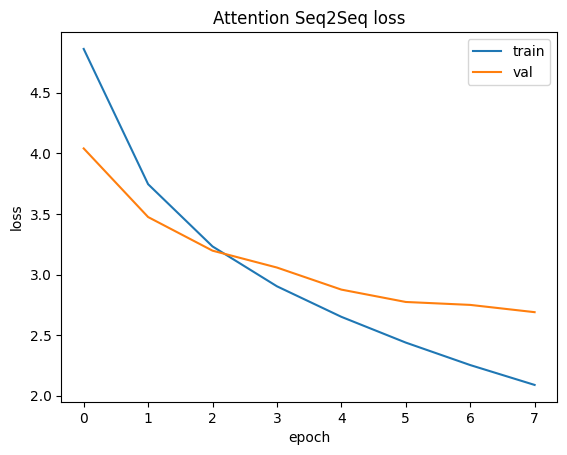

In [6]:
opt = torch.optim.Adam(model.parameters(), lr=LR)
crit = nn.CrossEntropyLoss(ignore_index=PAD)

def run_epoch(ds, train, desc):
    model.train(train); total, n = 0, 0
    bar = tqdm(make_batches(ds, BS, shuffle=train), desc=desc, leave=False)
    for b in bar:
        src, lens, tgt = collate(ds, b)
        with torch.set_grad_enabled(train):
            logits = model(src, lens, tgt)
            loss = crit(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))
        if train:
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        total += loss.item(); n += 1
        bar.set_postfix(loss=f"{total/n:.3f}")
    return total / n

start, best, tr_l, va_l = time.time(), 1e9, [], []
for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    tl = run_epoch(train_enc, True,  f"Epoch {ep}/{EPOCHS} train")
    vl = run_epoch(val_enc,   False, f"Epoch {ep}/{EPOCHS} val  ")
    tr_l.append(tl); va_l.append(vl)
    if vl < best:
        best = vl; torch.save(model.state_dict(), "best_attn.pt")
    print(f"Epoch {ep} | train {tl:.3f} | val {vl:.3f} (ppl {math.exp(vl):.1f}) | {time.time()-t0:.0f}s")
    if (time.time() - start) / 60 > TIME_BUDGET_MIN:
        print("Time budget khatam, training stop."); break

plt.plot(tr_l, label="train"); plt.plot(va_l, label="val"); plt.legend()
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Attention Seq2Seq loss")
plt.savefig("subtask2_loss.png", dpi=150); plt.show()

In [7]:
model.load_state_dict(torch.load("best_attn.pt")); model.eval()
V = len(tgt_itos)

def ids_to_words(seq):
    w = []
    for i in seq:
        if i == EOS: break
        w.append(tgt_itos[i])
    return w

# ---------- 1) Greedy (attention weights bhi return karta hai) ----------
@torch.no_grad()
def greedy_batch(src, lens, max_len=25, return_attn=False):
    enc_out, h, c = model.enc(src, lens); mask = src == PAD
    tok = torch.full((src.size(0), 1), SOS); outs, attns = [], []
    for _ in range(max_len):
        logits, h, c, a = model.dec(tok, h, c, enc_out, mask)
        tok = logits[:, -1].argmax(-1, keepdim=True)
        outs.append(tok); attns.append(a[:, -1])
    seqs = [ids_to_words(s) for s in torch.cat(outs, 1).tolist()]
    return (seqs, torch.stack(attns, 1)) if return_attn else seqs

In [9]:
# ---------- 2) Top-k sampling with temperature ----------
@torch.no_grad()
def sample_batch(src, lens, max_len=25, k=10, temp=0.8):
    enc_out, h, c = model.enc(src, lens); mask = src == PAD
    tok = torch.full((src.size(0), 1), SOS); outs = []
    for _ in range(max_len):
        logits, h, c, _ = model.dec(tok, h, c, enc_out, mask)
        lg = logits[:, -1] / temp
        topv, topi = lg.topk(k, -1)
        probs = F.softmax(topv, -1)
        tok = topi.gather(1, torch.multinomial(probs, 1))
        outs.append(tok)
    return [ids_to_words(s) for s in torch.cat(outs, 1).tolist()]


def decode_all(ds, fn, bs=256, desc=""):
    preds = [None] * len(ds)
    for b in tqdm(make_batches(ds, bs, shuffle=False), desc=desc, leave=False):
        src, lens, _ = collate(ds, b)
        for j, p in zip(b, fn(src, lens)): preds[j] = p
    return preds

In [10]:
# ---------- 3) Beam search (length-normalised) ----------
@torch.no_grad()
def beam_search(src_ids, k=5, max_len=25):
    src = torch.tensor([src_ids]); lens = torch.tensor([len(src_ids)])
    enc_out, h, c = model.enc(src, lens); mask = src == PAD
    seqs, scores, finished = [[SOS]], torch.zeros(1), []
    for _ in range(max_len):
        n = len(seqs)
        tok = torch.tensor([[s[-1]] for s in seqs])
        logits, h, c, _ = model.dec(tok, h, c, enc_out.expand(n, -1, -1), mask.expand(n, -1))
        logp = F.log_softmax(logits[:, -1], -1)
        top_s, top_i = (scores[:, None] + logp).view(-1).topk(2 * k)
        new_seqs, new_scores, new_idx = [], [], []
        for s, i in zip(top_s.tolist(), top_i.tolist()):
            b, w = divmod(i, V)
            if w == EOS:
                finished.append((s / len(seqs[b]), seqs[b][1:]))        # length normalisation
            else:
                new_seqs.append(seqs[b] + [w]); new_scores.append(s); new_idx.append(b)
            if len(new_seqs) == k: break
        if len(finished) >= k or not new_seqs: break
        seqs, scores = new_seqs, torch.tensor(new_scores)
        idx = torch.tensor(new_idx); h, c = h[:, idx], c[:, idx]
    if not finished:
        finished = [(scores[i].item() / len(seqs[i]), seqs[i][1:]) for i in range(len(seqs))]
    return [tgt_itos[i] for i in max(finished, key=lambda x: x[0])[1]]

def beam_all(ds, k):
    return [beam_search(ds[i][0], k=k) for i in tqdm(range(len(ds)), desc=f"beam k={k}", leave=False)]

In [11]:
def bleu_of(preds, data=test_data):
    hyps = [" ".join(p) for p in preds]
    refs = [" ".join(t) for _, t in data]
    return sacrebleu.corpus_bleu(hyps, [refs], tokenize="none", force=True), hyps, refs

strategies, times = {}, {}

t0 = time.time(); strategies["Greedy"] = decode_all(test_enc, greedy_batch, desc="greedy"); times["Greedy"] = time.time() - t0
torch.manual_seed(0)
t0 = time.time(); strategies["Top-k sampling (k=10, T=0.8)"] = decode_all(test_enc, sample_batch, desc="sampling"); times["Top-k sampling (k=10, T=0.8)"] = time.time() - t0
for k in (3, 5):
    t0 = time.time(); strategies[f"Beam (k={k})"] = beam_all(test_enc, k); times[f"Beam (k={k})"] = time.time() - t0

bleu_scores = {}
for name, preds in strategies.items():
    b, _, _ = bleu_of(preds)
    bleu_scores[name] = b.score
    unk = np.mean([w == "<unk>" for p in preds for w in p]) * 100
    rep = np.mean([any(p[i] == p[i+1] for i in range(len(p)-1)) for p in preds]) * 100
    print(f"{name:32s} BLEU {b.score:5.2f} | <unk> {unk:4.1f}% | repeat {rep:4.1f}% | {times[name]:.0f}s")

Greedy                           BLEU 13.62 | <unk> 14.7% | repeat 14.2% | 3s
Top-k sampling (k=10, T=0.8)     BLEU  9.24 | <unk> 12.7% | repeat 12.6% | 6s
Beam (k=3)                       BLEU 16.52 | <unk> 14.1% | repeat 15.1% | 81s
Beam (k=5)                       BLEU 16.20 | <unk> 13.8% | repeat 15.0% | 72s


,Model,Test BLEU
0,"Seq2Seq (no attention), greedy",7.76
1,"Seq2Seq + Luong attention, greedy",13.62
2,"Seq2Seq + Luong attention, beam k=5",16.20


,No attention,Attention
1-5,10.71,21.06
6-10,9.23,15.07
11-15,5.99,11.56


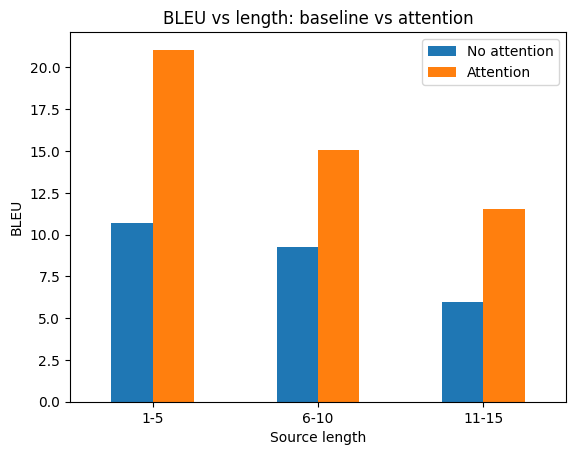

<unk> in predictions: baseline vs attention -> (Subtask 1 me 16.4%) vs 14.7%


In [12]:
base = json.load(open("../subtask1/subtask1_results.json"))
attn_greedy_bleu = bleu_scores["Greedy"]

rows = [("Seq2Seq (no attention), greedy", base["bleu"]),
        ("Seq2Seq + Luong attention, greedy", attn_greedy_bleu),
        ("Seq2Seq + Luong attention, beam k=5", bleu_scores["Beam (k=5)"])]
table = pd.DataFrame(rows, columns=["Model", "Test BLEU"]).round(2)
display(table)

# Length-bucket comparison (attention lambe sentences pe help karta hai ya nahi)
greedy_preds = strategies["Greedy"]
_, hyps_g, refs_g = bleu_of(greedy_preds)
attn_bucket = {}
for lo, hi in [(1, 5), (6, 10), (11, 15)]:
    idx = [i for i, (s, _) in enumerate(test_data) if lo <= len(s) <= hi]
    attn_bucket[f"{lo}-{hi}"] = sacrebleu.corpus_bleu([hyps_g[i] for i in idx], [[refs_g[i] for i in idx]],
                                                      tokenize="none", force=True).score
cmp = pd.DataFrame({"No attention": base["bleu_by_length"], "Attention": attn_bucket}).round(2)
display(cmp)

cmp.plot(kind="bar"); plt.ylabel("BLEU"); plt.xlabel("Source length"); plt.title("BLEU vs length: baseline vs attention")
plt.xticks(rotation=0); plt.savefig("subtask2_len_compare.png", dpi=150); plt.show()

unk_g = np.mean([w == "<unk>" for p in greedy_preds for w in p]) * 100
print(f"<unk> in predictions: baseline vs attention -> (Subtask 1 me 16.4%) vs {unk_g:.1f}%")

SRC   : but it hadn ' t .
REF   : mais non !
Greedy      : mais ce n ' est pas si .
Top-k sampli: mais cela n ' a pas reçu .
Beam (k=3)  : mais ce n ' était pas .
Beam (k=5)  : mais ce n ' était pas .

SRC   : i ' m learning not that i am luckier than them , though .
REF   : je n ' apprends pas que je suis plus chanceuse qu ' eux ,
Greedy      : je suis pas mal que je les <unk> , pas de <unk> .
Top-k sampli: je suis sans certain que je les <unk> , les <unk> <unk> .
Beam (k=3)  : je suis pas mal que je les <unk> , pas de <unk> .
Beam (k=5)  : je suis pas mal que j ' ai <unk> .

SRC   : i had a very normal , low - key kind of upbringing .
REF   : j ' ai eu une éducation tout à fait normale et tranquille .
Greedy      : j ' avais un <unk> très <unk> de plus , très <unk> .
Top-k sampli: je devais une très <unk> très <unk> comme une <unk> d ' <unk> .
Beam (k=3)  : j ' ai eu une <unk> très <unk> .
Beam (k=5)  : j ' ai eu une <unk> très <unk> .

SRC   : and now there are 10 , 000 parodies of 

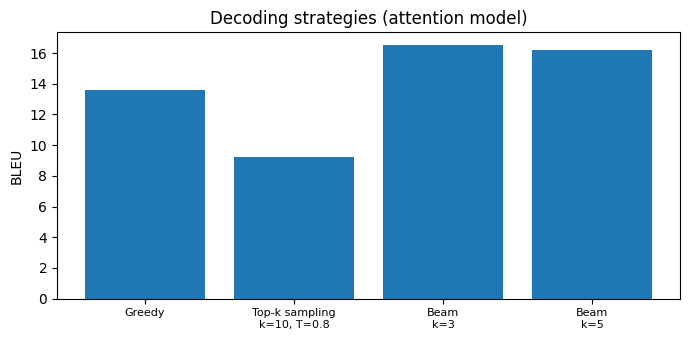

In [13]:
for i in [0, 1, 2, 3, 4, 5]:
    print("SRC   :", " ".join(test_data[i][0]))
    print("REF   :", " ".join(test_data[i][1]))
    for name, preds in strategies.items():
        print(f"{name[:12]:12s}:", " ".join(preds[i]))
    print()

# Beam k ka effect: bar chart
plt.figure(figsize=(7, 3.5))
plt.bar(range(len(bleu_scores)), list(bleu_scores.values()))
plt.xticks(range(len(bleu_scores)), [n.split(" (")[0] + ("\n" + n.split("(")[1][:-1] if "(" in n else "") for n in bleu_scores], fontsize=8)
plt.ylabel("BLEU"); plt.title("Decoding strategies (attention model)")
plt.tight_layout(); plt.savefig("subtask2_decoding.png", dpi=150); plt.show()

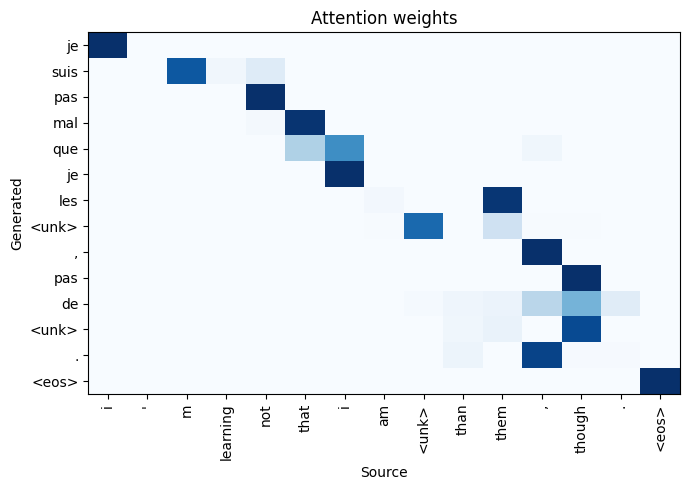

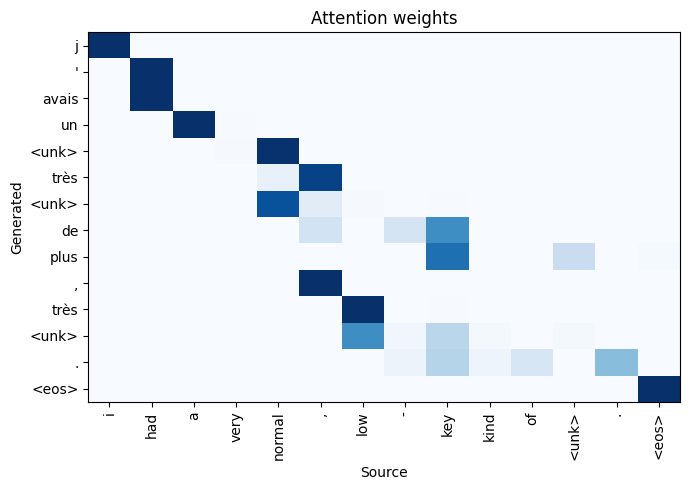

In [14]:
## Attention heatmap

def show_attention(i):
    src, lens, _ = collate(test_enc, [i])
    seqs, attn = greedy_batch(src, lens, return_attn=True)
    out = seqs[0]
    src_w = [src_itos[t] for t in src[0].tolist()]
    A = attn[0, :len(out) + 1, :].numpy()          # +1 => <eos> step bhi
    plt.figure(figsize=(7, 5))
    plt.imshow(A, cmap="Blues", aspect="auto")
    plt.xticks(range(len(src_w)), src_w, rotation=90)
    plt.yticks(range(len(out) + 1), out + ["<eos>"])
    plt.xlabel("Source"); plt.ylabel("Generated"); plt.title("Attention weights")
    plt.tight_layout(); plt.savefig(f"subtask2_attn_{i}.png", dpi=150); plt.show()

for i in [1, 2]:
    show_attention(i)

In [15]:
results = {"bleu_no_attention": base["bleu"], "bleu_attention_greedy": attn_greedy_bleu,
           "bleu_by_decoding": bleu_scores, "decode_time_sec": times,
           "bleu_by_length_no_attn": base["bleu_by_length"], "bleu_by_length_attn": attn_bucket,
           "best_val_loss": best, "epochs_run": len(tr_l)}
json.dump(results, open("subtask2_results.json", "w"), indent=2)
print(json.dumps(results, indent=2))

{
  "bleu_no_attention": 7.764214371552442,
  "bleu_attention_greedy": 13.62305930480617,
  "bleu_by_decoding": {
    "Greedy": 13.62305930480617,
    "Top-k sampling (k=10, T=0.8)": 9.241656587356557,
    "Beam (k=3)": 16.52254381416589,
    "Beam (k=5)": 16.196513625613015
  },
  "decode_time_sec": {
    "Greedy": 3.453169584274292,
    "Top-k sampling (k=10, T=0.8)": 5.862399101257324,
    "Beam (k=3)": 81.24210238456726,
    "Beam (k=5)": 72.40440130233765
  },
  "bleu_by_length_no_attn": {
    "1-5": 10.706198830599783,
    "6-10": 9.227135306586886,
    "11-15": 5.994867776882496
  },
  "bleu_by_length_attn": {
    "1-5": 21.058455943227884,
    "6-10": 15.072030651575496,
    "11-15": 11.555666668589506
  },
  "best_val_loss": 2.68920890490214,
  "epochs_run": 8
}
